### ML Classification

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import os

data_processed = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/processed")
print("Libraries loaded")

Libraries loaded


In [2]:
## Load feature matrix and run ML classification

data = pd.read_csv(f"{data_processed}/ML_feature_matrix.csv", index_col=0)

X = data.drop(columns=['disease_label'])
y = data['disease_label']

## Run all three classifiers using Stratified 5-fold cross validation
## Stratified ensures each fold maintains the same class distribution

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    "SVM": SVC(kernel='rbf', class_weight='balanced', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

Random Forest: 0.998 ± 0.005
XGBoost: 0.993 ± 0.014
SVM: 1.000 ± 0.000


In [3]:
## Save classification results
results_summary = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results_summary[name] = {'mean_accuracy': scores.mean(), 'std': scores.std()}

results_df = pd.DataFrame(results_summary).T
results_df.to_csv(f"{data_processed}/ML_classification_results.csv")
print(results_df)

               mean_accuracy       std
Random Forest       0.997619  0.004762
XGBoost             0.992857  0.014286
SVM                 1.000000  0.000000


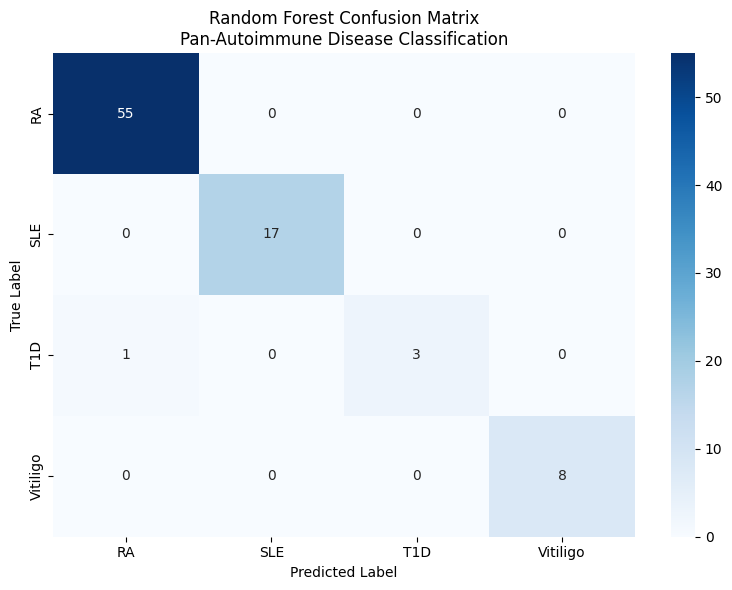

Confusion matrix saved


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import os

data_processed = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/processed")
figures_path = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/results/figures")

data = pd.read_csv(f"{data_processed}/ML_feature_matrix.csv", index_col=0)
X = data.drop(columns=['disease_label'])
y = data['disease_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels = ['RA', 'SLE', 'T1D', 'Vitiligo']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Random Forest Confusion Matrix\nPan-Autoimmune Disease Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{figures_path}/confusion_matrix.png", dpi=300)
plt.show()
print("Confusion matrix saved")